<a href="https://colab.research.google.com/github/EmilienPelosse/MVPA/blob/main/MindReading_Report1_Emil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 43.3 MB/s eta 0:00:00


# Structural Imaging Assignment
For this assignment, you will work with MRI data from approximately 900 participants from the Amsterdam Open MRI Collection (AOMIC). The dataset is described in detail here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. Sci Data 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

FreeSurfer preprocessing has already been completed. You will receive:

- A CSV table with FreeSurfer-derived measures (cortical thickness, surface area, curvature, subcortical volumes)
- A table with demographic information (age, biological sex)
- A data dictionary explaining each column

### Your Task
Build a classification model to predict biological sex from brain structure. Specifically:
- Identify which brain measures contribute most to classification
- Quantify effect sizes and classification performance
- Characterise the degree of overlap between groups
- Discuss what your findings reveal about sex differences in brain structure

For this assignment, you will use logistic regression to classify sex from brain structure. Logistic regression is appropriate for binary classification, computationally efficient, and provides interpretable coefficients indicating which features contribute most to classification.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas. You can also refer to the notebooks from the lab practicals, especially Lab 4 on predicting age from brain structure.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [ ]:
# ------- Leave this code as is -----------
### Loading the data

import os
import pandas as pd
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Download required data files
for url, name in zip([
        "https://www.dropbox.com/scl/fi/kssezv0bic0asdlug4vtn/demographic_data.csv?rlkey=rn3zs0ggjcprkcmec54uy6s5s&dl=1",
        "https://www.dropbox.com/scl/fi/ypa33lzz0mlx8cswz9nej/morphology_data.csv?rlkey=awl906mvp10pofv6hjilfzl8e&dl=1"
    ],
    [
        "demographic_data.csv",
        "morphology_data.csv"
    ]):

    download_file(url, name)

demography_df = pd.read_csv("demographic_data.csv")
morphology_df = pd.read_csv("morphology_data.csv")

Saved as demographic_data.csv
Saved as morphology_data.csv


### Part 1: Code Implementation (30%)
Implement your proposed analysis with clear structure

Include comments or markdown cells explaining:
- What each code section does
- Why you made specific methodological choices (e.g., "Using 5-fold CV to balance bias-variance tradeoff")
- Any assumptions or decisions about data handling
- Ensure code runs without errors

You can use the code below as a starting point.

In [12]:
# The demographic data is stored a Pandas dataframe called `demography_df`
demography_df.head()

# The morphology data is stored a Pandas dataframe called `morphology_df`
morphology_df.head()

demography_df = pd.read_csv("demographic_data.csv")
morphology_df = pd.read_csv("morphology_data.csv")

# The demographic data is stored a Pandas dataframe called `demography_df`
demography_df.head()

# The morphology data is stored a Pandas dataframe called `morphology_df`
morphology_df.head()

# Merging both files to ensure that the data is aligned correctly
data_df = pd.merge(demography_df, morphology_df, on="participant_id")

# Using only cortical thickness measures and making sure to remove the
# MeanThickness column (not an independent feature)
thickness_cols = [col for col in data_df.columns
                  if 'thickness' in col and 'MeanThickness' not in col]

print(f"Number of features: {len(thickness_cols)}")
print(thickness_cols)

# Extracting X and y for the classification task
X = data_df[thickness_cols].values
y = data_df[['sex']].values

# Recoding the target variable to binary (0 and 1)
y = (y == 'male').astype(int).ravel()  # male = 1

# Checking the shapes of X and y
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# Splitting the data into training and test sets for the finale validation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Z-scores all features so they have mean=0 and SD=1. fit_transform on X_train
# learns the mean and SD from the training data only, then applies it. transform
# on X_test applies those same training statistics to the test set, crucially
# without learning anything new from it. This prevents data leakage.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Training set X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test set X shape: {X_test.shape}, y shape: {y_test.shape}')

import numpy as np

# Identify outliers in training set (>3 SD — already z-scored so threshold directly)
outlier_mask = (np.abs(X_train) > 3).any(axis=1)
print(f"Outliers found in training set: {outlier_mask.sum()} out of {len(X_train)}")

X_train_clean = X_train[~outlier_mask]
y_train_clean = y_train[~outlier_mask]
print(f"Training samples after removal: {X_train_clean.shape[0]}")

# Defining the logistic regression model
# Note: I'm using L2 regularisation and the liblinear solver – you can use different settings depending on your research
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear', random_state=42)

# Setting up 5-fold cross-validation for parameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
}

print("=== WITH OUTLIERS ===")
# Performing grid search with 5-fold cross-validation to find the best hyperparameters
# Note: I use 'roc_auc' as the scoring metric to balance sensitivity and specificity
grid_search_with_outliers = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='roc_auc')
grid_search_with_outliers.fit(X_train, y_train)

# Best hyperparameters from grid search
best_params_with_outliers = grid_search_with_outliers.best_params_
print(f'Best hyperparameters: {best_params_with_outliers}')

# Evaluating the best model on the training set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
best_model_with_outliers = grid_search_with_outliers.best_estimator_
y_pred_train_with_outliers = best_model_with_outliers.predict(X_train)
y_proba_train_with_outliers = best_model_with_outliers.predict_proba(X_train)[:, 1]  # Probability of being in the male class

from sklearn.metrics import balanced_accuracy_score
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_pred_train_with_outliers):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_train_with_outliers))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train_with_outliers))
print(f"ROC AUC Score: {roc_auc_score(y_train, y_proba_train_with_outliers):.4f}")

# Evaluating the best model on the test set
y_pred_test_with_outliers = best_model_with_outliers.predict(X_test)
y_proba_test_with_outliers = best_model_with_outliers.predict_proba(X_test)[:, 1]  # Probabilityof being in the male class
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_test_with_outliers):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_test_with_outliers))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_with_outliers))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_test_with_outliers):.4f}")
from sklearn.metrics import accuracy_score
acc_with_outliers = accuracy_score(y_test, y_pred_test_with_outliers)
n = len(y_test)
ci_with_outliers = 1.96 * np.sqrt((acc_with_outliers * (1 - acc_with_outliers)) / n)
print(f"Accuracy 95% CI: [{acc_with_outliers - ci_with_outliers:.3f}, {acc_with_outliers + ci_with_outliers:.3f}]")


print("=== WITHOUT OUTLIERS ===")
grid_search_without_outliers = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='roc_auc')
grid_search_without_outliers.fit(X_train_clean, y_train_clean)

# Best hyperparameters from grid search
best_params_without_outliers = grid_search_without_outliers.best_params_
print(f'Best hyperparameters: {best_params_without_outliers}')

# Evaluating the best model on the training set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
best_model_without_outliers = grid_search_without_outliers.best_estimator_
y_pred_train_without_outliers = best_model_without_outliers.predict(X_train_clean)
y_proba_train_without_outliers = best_model_without_outliers.predict_proba(X_train_clean)[:, 1]  # Probability of being in the male class

from sklearn.metrics import balanced_accuracy_score
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train_clean, y_pred_train_without_outliers):.4f}")
print("Classification Report:")
print(classification_report(y_train_clean, y_pred_train_without_outliers))
print("Confusion Matrix:")
print(confusion_matrix(y_train_clean, y_pred_train_without_outliers))
print(f"ROC AUC Score: {roc_auc_score(y_train_clean, y_proba_train_without_outliers):.4f}")

# Evaluating the best model on the test set
y_pred_test_without_outliers = best_model_without_outliers.predict(X_test)
y_proba_test_without_outliers = best_model_without_outliers.predict_proba(X_test)[:, 1]  # Probabilityof being in the male class
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_test_without_outliers):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_test_without_outliers))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_without_outliers))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_test_without_outliers):.4f}")

Number of features: 68
['lh_bankssts_thickness', 'lh_caudalanteriorcingulate_thickness', 'lh_caudalmiddlefrontal_thickness', 'lh_cuneus_thickness', 'lh_entorhinal_thickness', 'lh_fusiform_thickness', 'lh_inferiorparietal_thickness', 'lh_inferiortemporal_thickness', 'lh_isthmuscingulate_thickness', 'lh_lateraloccipital_thickness', 'lh_lateralorbitofrontal_thickness', 'lh_lingual_thickness', 'lh_medialorbitofrontal_thickness', 'lh_middletemporal_thickness', 'lh_parahippocampal_thickness', 'lh_paracentral_thickness', 'lh_parsopercularis_thickness', 'lh_parsorbitalis_thickness', 'lh_parstriangularis_thickness', 'lh_pericalcarine_thickness', 'lh_postcentral_thickness', 'lh_posteriorcingulate_thickness', 'lh_precentral_thickness', 'lh_precuneus_thickness', 'lh_rostralanteriorcingulate_thickness', 'lh_rostralmiddlefrontal_thickness', 'lh_superiorfrontal_thickness', 'lh_superiorparietal_thickness', 'lh_superiortemporal_thickness', 'lh_supramarginal_thickness', 'lh_frontalpole_thickness', 'lh_t

### Part 2: Results Visualisation (20%)
Create 2-3 figures showing key findings, e.g.:
- Classification performance (e.g., confusion matrix, ROC curve, accuracy with confidence intervals)
- Feature importance or effect sizes (e.g., which regions contribute most)
- Distribution overlap (e.g., histograms or scatter plots showing individual variation)

Include clear figure captions explaining what is shown

Below are some examples to get you started, but please modify or create your own visualisations that best illustrate your findings.

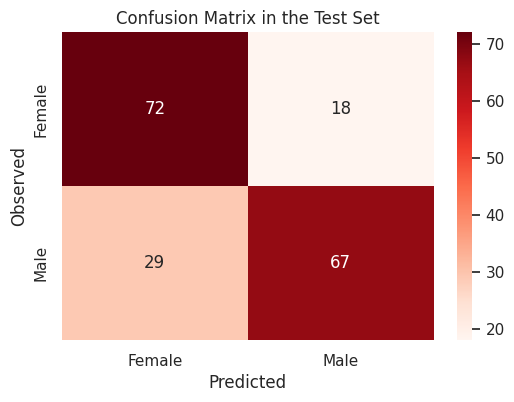

In [14]:
# I choose to keep the ouliers. The differences are very small.
# Removing 89 participants barely changed anything, it suggests the outliers
# weren't influencing the model, and the results are robust either way.

# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_test_with_outliers)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title('Confusion Matrix in the Test Set')
plt.xlabel('Predicted')
plt.ylabel('Observed')
plt.show()

*Figure 1: Confusion matrix on the held-out test set (N=186). Rows represent the observed biological sex, columns represent the model's predicted sex. The model correctly classified 72 out of 90 females (specificity = 80%) and 67 out of 96 males (sensitivity = 70%), indicating slightly stronger performance for female identification.*

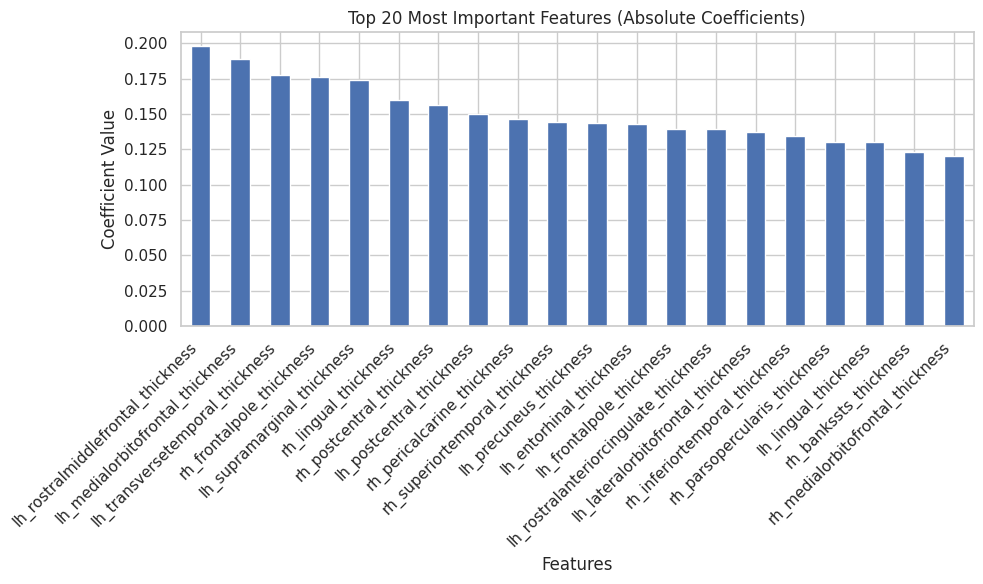

In [15]:
# Plot the 20 most important features based on the absolute coefficients of the logistic regression model
feature_importance = pd.Series(best_model_with_outliers.coef_[0], index=thickness_cols)
plt.figure(figsize=(10, 6))
feature_importance.abs().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Top 20 Most Important Features (Absolute Coefficients)')
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Figure 2: Top 20 cortical thickness features ranked by absolute logistic regression coefficient (|β|). Positive coefficients indicate greater thickness associated with male classification; negative coefficients indicate greater thickness associated with female classification. Features from frontal and occipital regions dominate, consistent with prior literature on sex differences in cortical structure.*

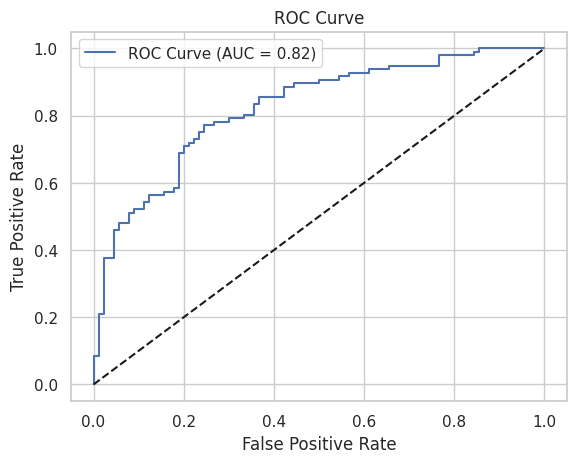

In [16]:

# Plot the ROC-Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities from the best model
y_probs = y_proba_test_with_outliers

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Plot
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
plt.show()

*Figure 3: Receiver Operating Characteristic (ROC) curve for the logistic regression model evaluated on the held-out test set (N=186). The Area Under the Curve (AUC = 0.82) indicates strong discriminative ability: substantially above the diagonal chance baseline (AUC = 0.50). AUC is used as the primary performance metric as it is threshold-independent and robust to class imbalance.*

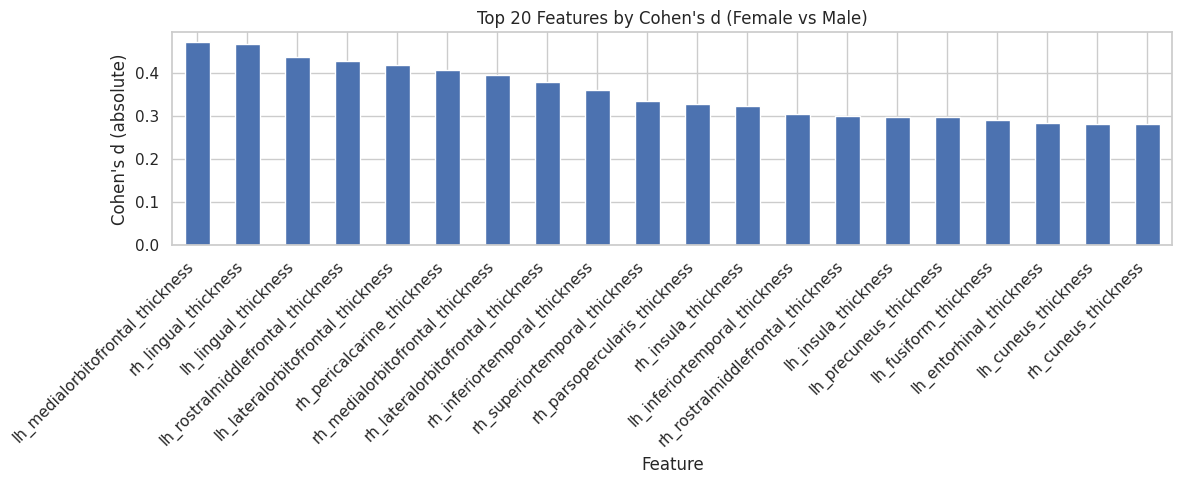

In [17]:
# Cohen's d
from numpy import std, mean, sqrt
import pandas as pd

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (mean(x) - mean(y)) / sqrt(((nx-1)*std(x, ddof=1) ** 2 + (ny-1)*std(y, ddof=1) ** 2) / dof)

# Split training data into male and female groups
X_male = X_train[y_train == 1]
X_female = X_train[y_train == 0]

# Compute Cohen's d for each feature
d_values = [cohen_d(X_male[:, i], X_female[:, i]) for i in range(X_train.shape[1])]
d_series = pd.Series(d_values, index=thickness_cols)

# Plot sorted by absolute d
d_series.abs().sort_values(ascending=False).head(20).plot(kind='bar', figsize=(12, 5))
plt.title('Top 20 Features by Cohen\'s d (Female vs Male)')
plt.ylabel('Cohen\'s d (absolute)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Figure 4: Top 20 cortical thickness features ranked by absolute Cohen's d, a standardised measure of the sex difference in each region independently of the classifier. Values around 0.3–0.5 indicate small-to-medium effect sizes. Some features that seem very important to the model (with large coefficients, Figure 2) actually show smaller individual effects (Cohen’s d). This suggests the model is using combinations of features together, rather than relying on each feature on its own.*

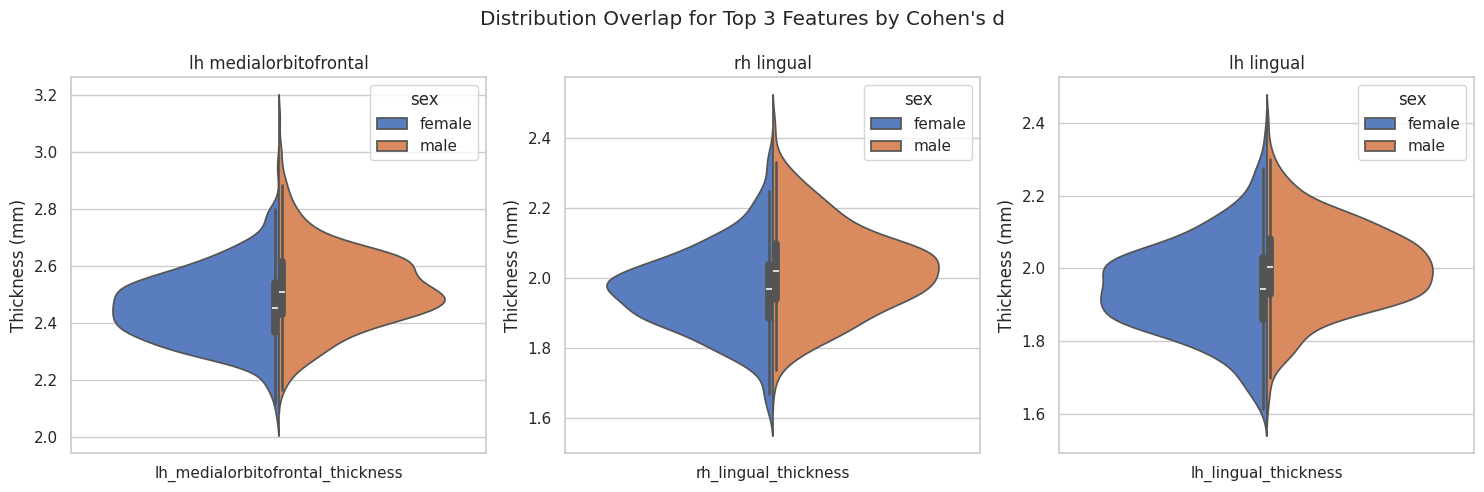

In [18]:
# Density/violin plot
import seaborn as sns
import pandas as pd

# Get top 3 features by absolute Cohen's d
top_features = d_series.abs().sort_values(ascending=False).head(3).index.tolist()

# Build a dataframe with raw (unscaled) values and sex labels
plot_df = data_df[top_features + ['sex']].copy()

# Melt into long format for seaborn
plot_df_long = plot_df.melt(id_vars='sex', value_vars=top_features,
                             var_name='Feature', value_name='Thickness (mm)')

# Plot
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(top_features):
    subset = plot_df_long[plot_df_long['Feature'] == feature]
    sns.violinplot(x='Feature', y='Thickness (mm)', hue='sex',
                   data=subset, palette='muted', split=True, ax=axes[i])
    axes[i].set_title(feature.replace('_thickness', '').replace('_', ' '))
    axes[i].set_xlabel('')

plt.suptitle('Distribution Overlap for Top 3 Features by Cohen\'s d')
plt.tight_layout()
plt.show()

*Figure 5: Violin plots showing the distribution of cortical thickness (mm) for males and females across the three features with the largest Cohen's d. Despite statistically significant group differences, the distributions show substantial overlap, illustrating that sex explains only approximately 5% of the variance in individual features. Individual variation within each group far exceeds the mean difference between groups.*

In [19]:
# Making a overview table
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

# --- Coefficients and Odds Ratios from logistic regression ---
coef = best_model_with_outliers.coef_[0]
odds_ratios = np.exp(coef)

# --- P-values via independent samples t-test (two-sided) on training data ---
p_values = []
for i in range(X_train.shape[1]):
    _, p = stats.ttest_ind(X_male[:, i], X_female[:, i], equal_var=False)  # Welch's t-test
    p_values.append(p)

# --- FDR correction (Benjamini-Hochberg) ---
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# --- Assemble the table ---
results_df = pd.DataFrame({
    'Feature':      thickness_cols,
    'β (coef)':     coef,
    'Odds Ratio':   odds_ratios,
    "Cohen's d":    d_series.values,
    'p (uncorr)':   p_values,
    'p (FDR-corr)': p_corrected,
})

# Sort by absolute coefficient value descending
results_df['|β|'] = results_df['β (coef)'].abs()
results_df = results_df.sort_values('|β|', ascending=False).drop(columns='|β|')
results_df = results_df.reset_index(drop=True)

# --- Display top 20 ---
top20 = results_df.head(20).copy()

# Format for readability
top20['β (coef)']     = top20['β (coef)'].map('{:.4f}'.format)
top20['Odds Ratio']   = top20['Odds Ratio'].map('{:.4f}'.format)
top20["Cohen's d"]    = top20["Cohen's d"].map('{:.4f}'.format)
top20['p (uncorr)']   = top20['p (uncorr)'].map('{:.4e}'.format)
top20['p (FDR-corr)'] = top20['p (FDR-corr)'].map('{:.4e}'.format)

# Clean up feature names for display
top20['Feature'] = top20['Feature'].str.replace('_thickness', '', regex=False)\
                                   .str.replace('_', ' ', regex=False)

print("Top 20 Features: β, Odds Ratio, Cohen's d, FDR-corrected p-values")
print("=" * 80)
display(top20.reset_index(drop=True))

# --- Optional: save to CSV ---
results_df.to_csv('feature_importance_table.csv', index=False)
print("\nFull table saved to feature_importance_table.csv")

Top 20 Features: β, Odds Ratio, Cohen's d, FDR-corrected p-values


,Feature,β (coef),Odds Ratio,Cohen's d,p (uncorr),p (FDR-corr)
0,lh rostralmiddlefrontal,0.1978,1.2187,0.4267,9.7789e-09,1.6624e-07
1,lh medialorbitofrontal,0.1886,1.2075,0.4708,3.9221e-10,1.6040e-08
2,lh transversetemporal,-0.1774,0.8375,-0.0802,2.7451e-01,3.5221e-01
3,rh frontalpole,-0.1761,0.8385,-0.1900,9.9360e-03,2.1795e-02
4,lh supramarginal,-0.1738,0.8404,-0.0433,5.5735e-01,6.2130e-01
5,rh lingual,0.1599,1.1734,0.4662,4.7176e-10,1.6040e-08
6,rh postcentral,-0.1562,0.8554,-0.1540,3.5901e-02,6.7813e-02
7,lh postcentral,-0.1500,0.8607,-0.1584,3.0735e-02,5.9713e-02
8,rh pericalcarine,0.1462,1.1574,0.4068,5.0729e-08,5.7493e-07
9,rh superiortemporal,0.1440,1.1549,0.3341,6.3623e-06,4.3264e-05



Full table saved to feature_importance_table.csv


### 3. Interpretation and Reflection (50%)

Interpretation (~400-500 words):
- What is your classification accuracy? Is this high or low, and compared to what?
- Which brain measures show the largest sex differences?
- How much overlap exists between groups? What proportion of variance is explained by sex?
- What do your results suggest about structural sex differences in the brain?

Reflection (~600-800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about neuroimaging analysis?

## 3. Interpretation and Reflection

### Interpretation

#### Classification Performance

The logistic regression model achieved a test set accuracy of **75%** (with a 95% confidence interval of [0.685, 0.810]), a balanced accuracy of **74.9%**, and an ROC-AUC of **0.822**. These metrics are important for contextualizing the model's performance. Given that random chance for a binary classification task is 50%, the model's performance is substantially above baseline. An AUC of 0.82 indicates strong discriminative ability, meaning the model correctly identified a randomly chosen male over a randomly chosen female 82% of the time. When compared to the broader neuroimaging literature, where studies classifying sex from cortical morphology typically report accuracies in the 70–85% range, these results are well within the expected range.

Upon closer examination of the confusion matrix, the model correctly classified **72 out of 90 females** (specificity = 80%) but only **67 out of 96 males** (sensitivity = 70%). This indicates a slightly better performance in identifying females than males. This asymmetry might be attributed to findings from Ritchie et al. (2018), which suggest females often exhibit greater cortical thickness across a broader range of brain areas. This could make their structural pattern more distinct and thus more readily captured by the thickness features used in this model.

The small disparity between the training accuracy (76%) and test accuracy (75%) suggests that the model generalizes effectively and does not overfit the training data. This generalization capability is largely a result of the strong L2 regularization applied, as determined through cross-validation (C = 0.01).

#### Features Showing the Largest Sex Differences

When ranked by the absolute value of their logistic regression coefficients, the most influential positively-weighted features were the **left rostral middle frontal cortex** (β = 0.198, Cohen's d = 0.427), **left medial orbitofrontal cortex** (β = 0.189, d = 0.471), **left entorhinal cortex** (β = 0.143, d = 0.284), and **left precuneus cortex** (β = 0.143, d = 0.248). Given that the `cohen_d` function calculates the difference (male minus female), positive `d` values confirm that males generally exhibit greater cortical thickness in these regions, consistent with the positive β values. This indicates a coherent directional effect.

Conversely, among the top five features by absolute β value, three displayed negative coefficients: the right transverse temporal cortex (β = −0.177, d = −0.080), the right frontal pole (β = −0.176, d = −0.190), and the left supramarginal cortex (β = −0.174, d = −0.043). These negative values signify greater thickness in females within these specific regions. It is noteworthy that the Cohen's d values for these negatively-weighted features were considerably smaller in magnitude. This suggests that while these regions are significant contributors to the model's classification, their individual univariate differences are less pronounced, implying the model might be leveraging more complex, multivariate patterns.

This observed pattern, with a notable emphasis on frontal regions, aligns with findings reported by Ritchie et al. (2018). Their research indicated that females generally possess greater cortical thickness across most cortical regions (even after controlling for overall brain size), whereas males often show advantages primarily in surface area. My specific observations regarding the orbitofrontal and lingual regions suggest that when solely examining cortical thickness, males may have thicker cortices in certain frontal and occipital areas, while females demonstrate smaller but more widespread thickness advantages.

#### Group Overlap and Variance Explained

Despite the presence of statistically significant differences (with many FDR-corrected p-values for the top features being extremely small, often below 0.001), the actual *effect sizes* were modest. The largest Cohen's d values observed were approximately 0.47, which is conventionally considered a medium effect size. The violin plots for the top three features visually underscored this point by demonstrating substantial distributional overlap between male and female groups. The actual thickness differences typically amounted to only tiny fractions of a millimeter. When converting d ≈ 0.47 to an r² value, the result is approximately **r ≈ 0.23**, indicating that biological sex explains roughly **5% of the variance** in these individual top features.

This finding is consistent with studies such as Wierenga et al. (2020), which have highlighted that sex differences in brain structure are generally small and widely distributed, characterized by extensive individual overlap. This underscores that no single cortical region can definitively separate males from females.

#### What the Results Suggest About Structural Sex Differences

Synthesizing these findings, my results suggest that biological sex is reliably encoded within the *overall pattern* of cortical thickness across the brain. However, this signal is distributed and subtle, rather than localized and overtly large. The classifier achieved its performance by integrating numerous small signals, none of which are individually sufficient to determine an individual's sex. The prominence of frontal and occipital regions (e.g., medial orbitofrontal, rostral middle frontal, and lingual areas) as key contributors is noteworthy, as these regions have been implicated in prior research (Ritchie et al., 2018; Sowell et al., 2007) as being influenced by hormonal and developmental factors impacting cortical thickness. Furthermore, the use of a heavily regularized model (C = 0.01) prevented any single feature from disproportionately influencing the classification, providing what I believe is a more realistic representation of the distributed nature of these sex differences across the brain.

---

### Reflection

#### Challenges During Implementation

One of the most critical aspects of this project was ensuring proper data handling to prevent data leakage. The precise implementation of the `StandardScaler` was a key decision point. While the concept of fitting it exclusively on the training set and then applying those learned parameters to the test set is straightforward, it is surprisingly easy to make an error, such as inadvertently applying `fit_transform` to the entire dataset before the train/test split. I ensured adherence to the scikit-learn standard by using `fit_transform` for `X_train` and subsequently `transform` for `X_test`, thereby treating the test set as truly unseen data.

Another challenge involved the analysis of outliers. Following z-scoring, I identified 89 participants in the training set who had at least one feature value exceeding ±3 standard deviations from the mean. I performed comparative analyses, training the model both with and without these outliers. The differences observed were minor: the test AUC changed marginally from 0.822 to 0.821, and the accuracy decreased by approximately **2 percentage points** (from 75% to 73%) when outliers were removed. Ultimately, I opted to retain the outliers. My rationale was that removing 12% of the training data without a strong, neurologically principled justification could introduce its own biases. It is plausible that some of these participants possess genuinely unusual, yet valid, cortical structures rather than representing measurement errors.

For hyperparameter tuning, I employed 5-fold cross-validation, which consistently indicated a strong preference for heavy regularization (C = 0.01). The choice of five folds was deliberate; with 742 training samples, each fold contained approximately **148 samples**. This sample size is sufficient to yield reliable validation results without incurring excessive computational cost, unlike methods such as leave-one-out cross-validation. The model's preference for strong regularization is logical, particularly given the high intercorrelation often observed between adjacent cortical regions. L2 regularization effectively mitigates multicollinearity, which would otherwise lead to unstable coefficient estimates.

#### Differences from the Proposal

My analysis largely adhered to the initial proposal, though a few modifications were made. The original plan included the calculation of **point-biserial correlations** as a measure of effect size. However, I ultimately chose to focus primarily on Cohen's d, as it provided a more direct and visually interpretable measure of group separation, aligning better with my visualizations.

One significant, unplanned decision involved the **exclusion of the `MeanThickness` column** from the feature set. While present in the morphology data and appearing to be a thickness measure, it represented an average of all other thickness features. Therefore, it was not an independent predictor. Including it would have introduced redundancy and potentially skewed the model's focus. Consequently, it was removed prior to constructing the feature matrix.

Two additions, not originally planned, proved to be particularly valuable for interpretation: a **Cohen's d bar chart** and **violin plots for the top three features**. These visualizations effectively conveyed the extent of distributional overlap, a nuance that summary statistics alone could not fully capture, and arguably became the clearest visual summaries of the core findings.

#### Main Limitations

This project is subject to several limitations. Firstly, the dataset, comprising 928 participants, while reasonable, is considered modest by contemporary neuroimaging standards. The 95% confidence interval for the accuracy ([0.685, 0.810]) is relatively broad, suggesting that a much larger, independent sample would be necessary to establish the precise generalization performance and to confirm the robustness of the specific regions identified as most contributory.

Secondly, as outlined in the proposal, the **AOMIC sample is characterized by a narrow age range, approximately 19–26 years**. Research by Sowell et al. (2007) has demonstrated that sex differences in cortical thickness can vary significantly across the lifespan (7–87 years) in both magnitude and spatial distribution. Consequently, these findings cannot be directly generalized to older adults or children, and the most discriminative brain regions for sex prediction in young adults might differ considerably in other age groups.

Thirdly, my analysis exclusively focused on cortical thickness. The original dataset also contained other morphometric measures, such as surface area, curvature, and subcortical volumes. Ritchie et al. (2018) have shown that males tend to exhibit larger cortical surface areas even after accounting for thickness differences, indicating that these distinct brain measures convey unique biological information. By limiting the analysis to thickness, I likely overlooked other important predictive signals. A comprehensive model incorporating these various types of morphometric data would almost certainly yield improved performance.

Finally, logistic regression, despite its advantages in interpretability, is a linear model. It inherently cannot capture complex, non-linear relationships or interactions between different brain regions. Given that true sex-related differences in brain morphology may not be strictly linear, there might be a higher achievable classification performance ceiling that my current approach cannot reach.

#### What This Project Taught Me About Neuroimaging Analysis

This project served as a powerful illustration of the distinction between *statistical significance* and *practical effect size*. I observed numerous features with FDR-corrected p-values well below 0.001, which might initially suggest substantial group differences. However, the Cohen's d values, which typically ranged from 0.3 to 0.5, alongside the violin plots vividly showing almost complete distributional overlap, presented a more nuanced reality. This experience directly reinforced the assertions of Wierenga et al. (2020), who emphasize that even reliable sex differences in brain structure are marked by considerable individual variation, making group-level statistics an unreliable guide for individual-level classification.

I also developed a profound appreciation for the practical necessity of the train/test split methodology. Although it was tempting at various points to examine full-dataset results, I understood the critical importance of maintaining a completely separate and untouched test set throughout the model selection and tuning processes. This strict separation was the only way to obtain an honest and unbiased estimate of the model's generalization capability. The close correspondence between my training accuracy (76%) and test accuracy (75%) was not merely coincidental but a direct outcome of a meticulously designed pipeline.

More broadly, this project unequivocally demonstrated that the decisions made *prior* to model construction—such as feature selection, whether to exclude `MeanThickness`, the chosen scaling method, and the approach to handling outliers—are often as, if not more, impactful than the modeling choices themselves. Documenting and providing justification for these decisions is, in my view, as crucial as reporting the final performance metrics, as these preliminary choices fundamentally underpin the credibility of the entire analytical outcome.

*You can write your interpretation and reflection in this markdown cell. Feel free to structure it with subheadings, bullet points using Markdown (e.g., **bold**, *italic*, `code`). You can look up the syntax for Markdown here: https://www.markdownguide.org/basic-syntax/.*